# Take-Home Assessment 3: Creative Component

In class, we will mostly look at scatter and bar plots. However, `seaborn` offers a *bunch* of other different kinds of visualizations! In this creative component, take a look through `seaborn`'s [<u>Example Gallery</u>](https://seaborn.pydata.org/examples/index.html) to choose **two different visualizations** for the following coding task:

> Create two plots that use the educational attainment `data` and a racial category of your choice. The resulting plot should compare each of the 4 Min degree options, indicating the percentage of educational attainment for the given racial category and `Min degree` over the entire time range of available data. Due to missing data, not all min degree options will stretch the entire width of the plot. Label the x-axis `"Year"`, the y-axis `"Percentage"`, and give the plot an appropriate title.

Note: not all visualization types will be well-suited for this task. That's OK! We will ask for your reflection on effectiveness and suitability of your visualizations.

In the code cells provided, write code for **2 distinct visualizations** according to `seaborn`'s documentation. These should be visualizations that we have *not* covered in class! Then, explain your choice of visualization for each plot and explain whether you think it is effective or not.

You are not required to write functions for these visualizations, but you should show the output of your visualizations in the notebook.

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv(
    "nces-ed-attainment.csv",
    na_values=["---"],
    index_col=["Year", "Sex", "Min degree"]
).sort_index()

race_col = "Black" 
sns.set_theme()
df = data.loc[(slice(None), "A", slice(None)), [race_col]].reset_index()
df = df.rename(columns={race_col: "Percentage"})
df = df[df["Min degree"].isin(["high school", "associate's", "bachelor's", "master's"])]

Text(0.5, 1.02, 'Black educational attainment over time (lmplot)')

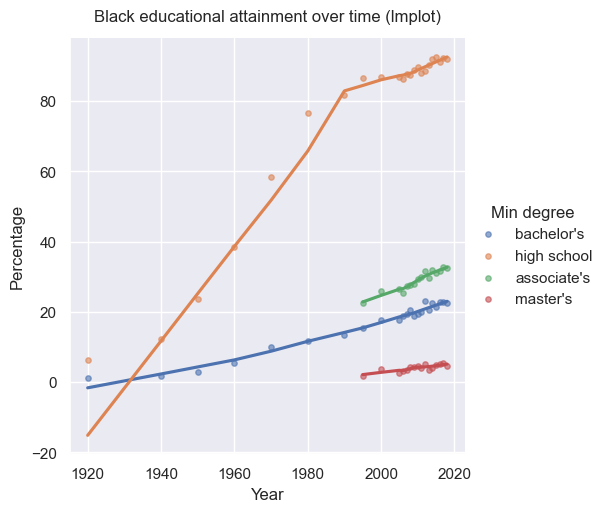

In [8]:
# Your first visualization here!
sns.lmplot(
    data=df,
    x="Year",
    y="Percentage",
    hue="Min degree",
    lowess=True,
    scatter_kws={"s": 15, "alpha": 0.6}
)
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.title(f"{race_col} educational attainment over time (lmplot)", y=1.02)

For the above visualization, answer the following:

### What type of visualization did you choose?

A lmplot


### Why did you choose this visualization type?

I chose an lmplot because I felt it clearly shows patterns and trends over time in the data. The shape of the lines makes the changes easy to follow, and I found it simple to interpret at a glance. It also felt like a good way to visually summarize how educational attainment has changed over the years.


### What is effective about this visualization choice?

It effectively shows how educational attainment has changed over time for each degree level. Using color to distinguish minimum degree levels makes comparisons between degrees clear.


### What is ineffective about this visualization choice?

The lmplot can appear cluttered since multiple degree levels are plotted on the same axes. Also, the regression lines may imply a stronger or more linear relationship than actually exists in the raw data.

Text(0.5, 1.02, 'Black educational attainment distribution by degree (boxplot)')

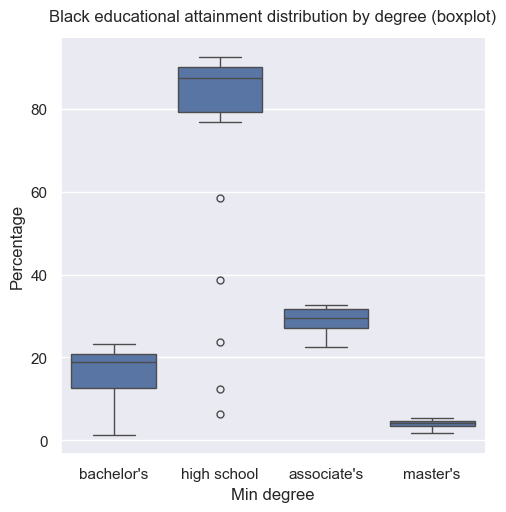

In [9]:
# Your second visualization here!
sns.catplot(
    data=df,
    x="Min degree",
    y="Percentage",
    kind="box"
)
plt.xlabel("Min degree")
plt.ylabel("Percentage")
plt.title(f"{race_col} educational attainment distribution by degree (boxplot)", y=1.02)

For the above visualization, answer the following:

### What type of visualization did you choose?

A box plot


### Why did you choose this visualization type?

I chose a boxplot because I am already familiar with this type of visualization from my statistics class and feel comfortable interpreting it. Since I understand how boxplots show distributions and comparisons, it just felt convenient to use one here. I also thought it would be nice to apply something I already know to this dataset.


### What is effective about this visualization choice?

The boxplot clearly shows differences in spread and central tendency between degree levels. It also shows outliers and variability that are not easily seen in line-based visualizations.

### What is ineffective about this visualization choice?

The boxplot removes the temporal dimension, so it does not show how attainment changes year by year. Because of that, trends over time are harder to interpret compared to time-based plots like lmplot.
